# Import

In [1]:
from parcels import (
        FieldSet,
        JITParticle,
        ScipyParticle,
        ParticleSet,
        AdvectionRK4,
        AdvectionRK4_3D,
        StatusCode,
)
import parcels

import datetime as dt
from datetime import datetime, timedelta

import dask

import numpy as np
from numpy.random import uniform, randint

from pathlib import Path
import geopandas as gpd
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors
import cmocean

import xarray as xr
from glob import glob
import cartopy
import cartopy.crs as ccrs
from time import time
import warnings
import shapely
import itertools



warnings.simplefilter("ignore")

# Set Parameters

In [2]:
zarr_path = Path("/gxfs_work/geomar/smomw597/2025_Fucus/output/Trajectories/2021/TEST_Nested_20210101-20210108_dt60min_N500_seed123.zarr")
ds_trajectories = xr.open_zarr(zarr_path).compute()
ds_trajectories

<xarray.Dataset> Size: 10MB
Dimensions:     (trajectory: 500, obs: 408)
Coordinates:
  * obs         (obs) int32 2kB 0 1 2 3 4 5 6 7 ... 401 402 403 404 405 406 407
  * trajectory  (trajectory) int64 4kB 0 1 2 3 4 5 6 ... 494 495 496 497 498 499
Data variables:
    CellID      (trajectory, obs) float32 816kB 4.971e+04 4.971e+04 ... nan nan
    S           (trajectory, obs) float32 816kB 5.85 5.85 5.85 ... nan nan nan
    T           (trajectory, obs) float32 816kB 1.883 1.85 1.828 ... nan nan nan
    age_sec     (trajectory, obs) float32 816kB 0.0 0.0 0.0 0.0 ... nan nan nan
    lat         (trajectory, obs) float64 2MB 63.04 63.04 63.03 ... nan nan nan
    lon         (trajectory, obs) float64 2MB 20.99 20.98 20.97 ... nan nan nan
    time        (trajectory, obs) datetime64[ns] 2MB 2021-01-01T06:45:00 ... NaT
    z           (trajectory, obs) float64 2MB 0.0 0.0 0.0 0.0 ... nan nan nan
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        NewParticleAdvectionRK4_2D_SIGMABSHdelete_error_p...
    parcels_mesh:           spherical
    parcels_version:        3.0.6

In [3]:
release_area_path = Path("/gxfs_work/geomar/smomw597/2025_Fucus/2025_fucus-dispersal/Fucus_location_shp")
gdf_release_area = gpd.read_file(Path(release_area_path, "REDLIST_SIS_Macrophytes.geojson"))[["CELLCODE"]]

In [4]:
try: ds_trajectories = ds_trajectories.rename(dict(CellID="cell_IDs"))
except: ds_trajectories

In [5]:
try: list_cell_IDs = ds_trajectories.cell_IDs.isel(obs=0).values.astype(int)
except: ""
cell_codes = gdf_release_area.loc[list_cell_IDs].values.flatten().astype(str)
trajectories = ds_trajectories.trajectory.values
multi_idx_traj_cellID = pd.MultiIndex.from_arrays(
        arrays=[trajectories, list_cell_IDs],
        names=("trajectory_ID", "cell_ID"),
)
traj_coords = xr.Coordinates.from_pandas_multiindex(multi_idx_traj_cellID, "trajectory")

In [6]:
ds_trajectories = ds_trajectories.assign_coords(traj_coords)
ds_trajectories = ds_trajectories.assign_coords(dict(cell_code=("trajectory", cell_codes)))
ds_trajectories

<xarray.Dataset> Size: 10MB
Dimensions:        (trajectory: 500, obs: 408)
Coordinates:
  * obs            (obs) int32 2kB 0 1 2 3 4 5 6 ... 401 402 403 404 405 406 407
  * trajectory     (trajectory) object 4kB MultiIndex
  * trajectory_ID  (trajectory) int64 4kB 0 1 2 3 4 5 ... 495 496 497 498 499
  * cell_ID        (trajectory) int64 4kB 49710 49718 49705 ... 49702 49714
    cell_code      (trajectory) <U12 24kB '10kmE487N448' ... '10kmE496N421'
Data variables:
    cell_IDs       (trajectory, obs) float32 816kB 4.971e+04 4.971e+04 ... nan
    S              (trajectory, obs) float32 816kB 5.85 5.85 5.85 ... nan nan
    T              (trajectory, obs) float32 816kB 1.883 1.85 1.828 ... nan nan
    age_sec        (trajectory, obs) float32 816kB 0.0 0.0 0.0 ... nan nan nan
    lat            (trajectory, obs) float64 2MB 63.04 63.04 63.03 ... nan nan
    lon            (trajectory, obs) float64 2MB 20.99 20.98 20.97 ... nan nan
    time           (trajectory, obs) datetime64[ns] 2MB 2021-01-01T06:45:00 ....
    z              (trajectory, obs) float64 2MB 0.0 0.0 0.0 0.0 ... nan nan nan
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        NewParticleAdvectionRK4_2D_SIGMABSHdelete_error_p...
    parcels_mesh:           spherical
    parcels_version:        3.0.6

statistics of in which month and from which starting position do the particles travel how far, and the area

In [7]:
release_dates = ds_trajectories.isel(obs=0).time.values
release_dates = np.array([release_dates] * len(ds_trajectories.obs)).T
ds_release_dates = xr.Dataset(data_vars=dict(release_date=(["trajectory", "obs"], release_dates)))
try: ds_trajectories = xr.merge([ds_trajectories, ds_release_dates],) 
except: ds_trajectories

In [8]:
valid_obs_count = ds_trajectories.lat.notnull().sum(dim="obs", skipna=True).values
ds_valid_obs_count = xr.Dataset(data_vars=dict(valid_obs_count=("trajectory", valid_obs_count)))
try: ds_trajectories = xr.merge([ds_trajectories, ds_valid_obs_count],) 
except: ds_trajectories

In [9]:
lat_diff = ds_trajectories.lat.isel(obs=[0,-1]).diff(dim="obs").values.flatten()
lon_diff = ds_trajectories.lon.isel(obs=[0,-1]).diff(dim="obs").values.flatten()
ds_latlon_diff = xr.Dataset(
        data_vars=dict(
                lat_diff=("trajectory", lat_diff),
                lon_diff=("trajectory", lon_diff),
        )
)
try: ds_trajectories = xr.merge([ds_trajectories, ds_latlon_diff],) 
except: ds_trajectories

In [10]:
lon_min, lon_max = (9,30)
lat_min, lat_max = (52,66)
lon_range = lon_max-lon_min
lat_range = lat_max-lat_min

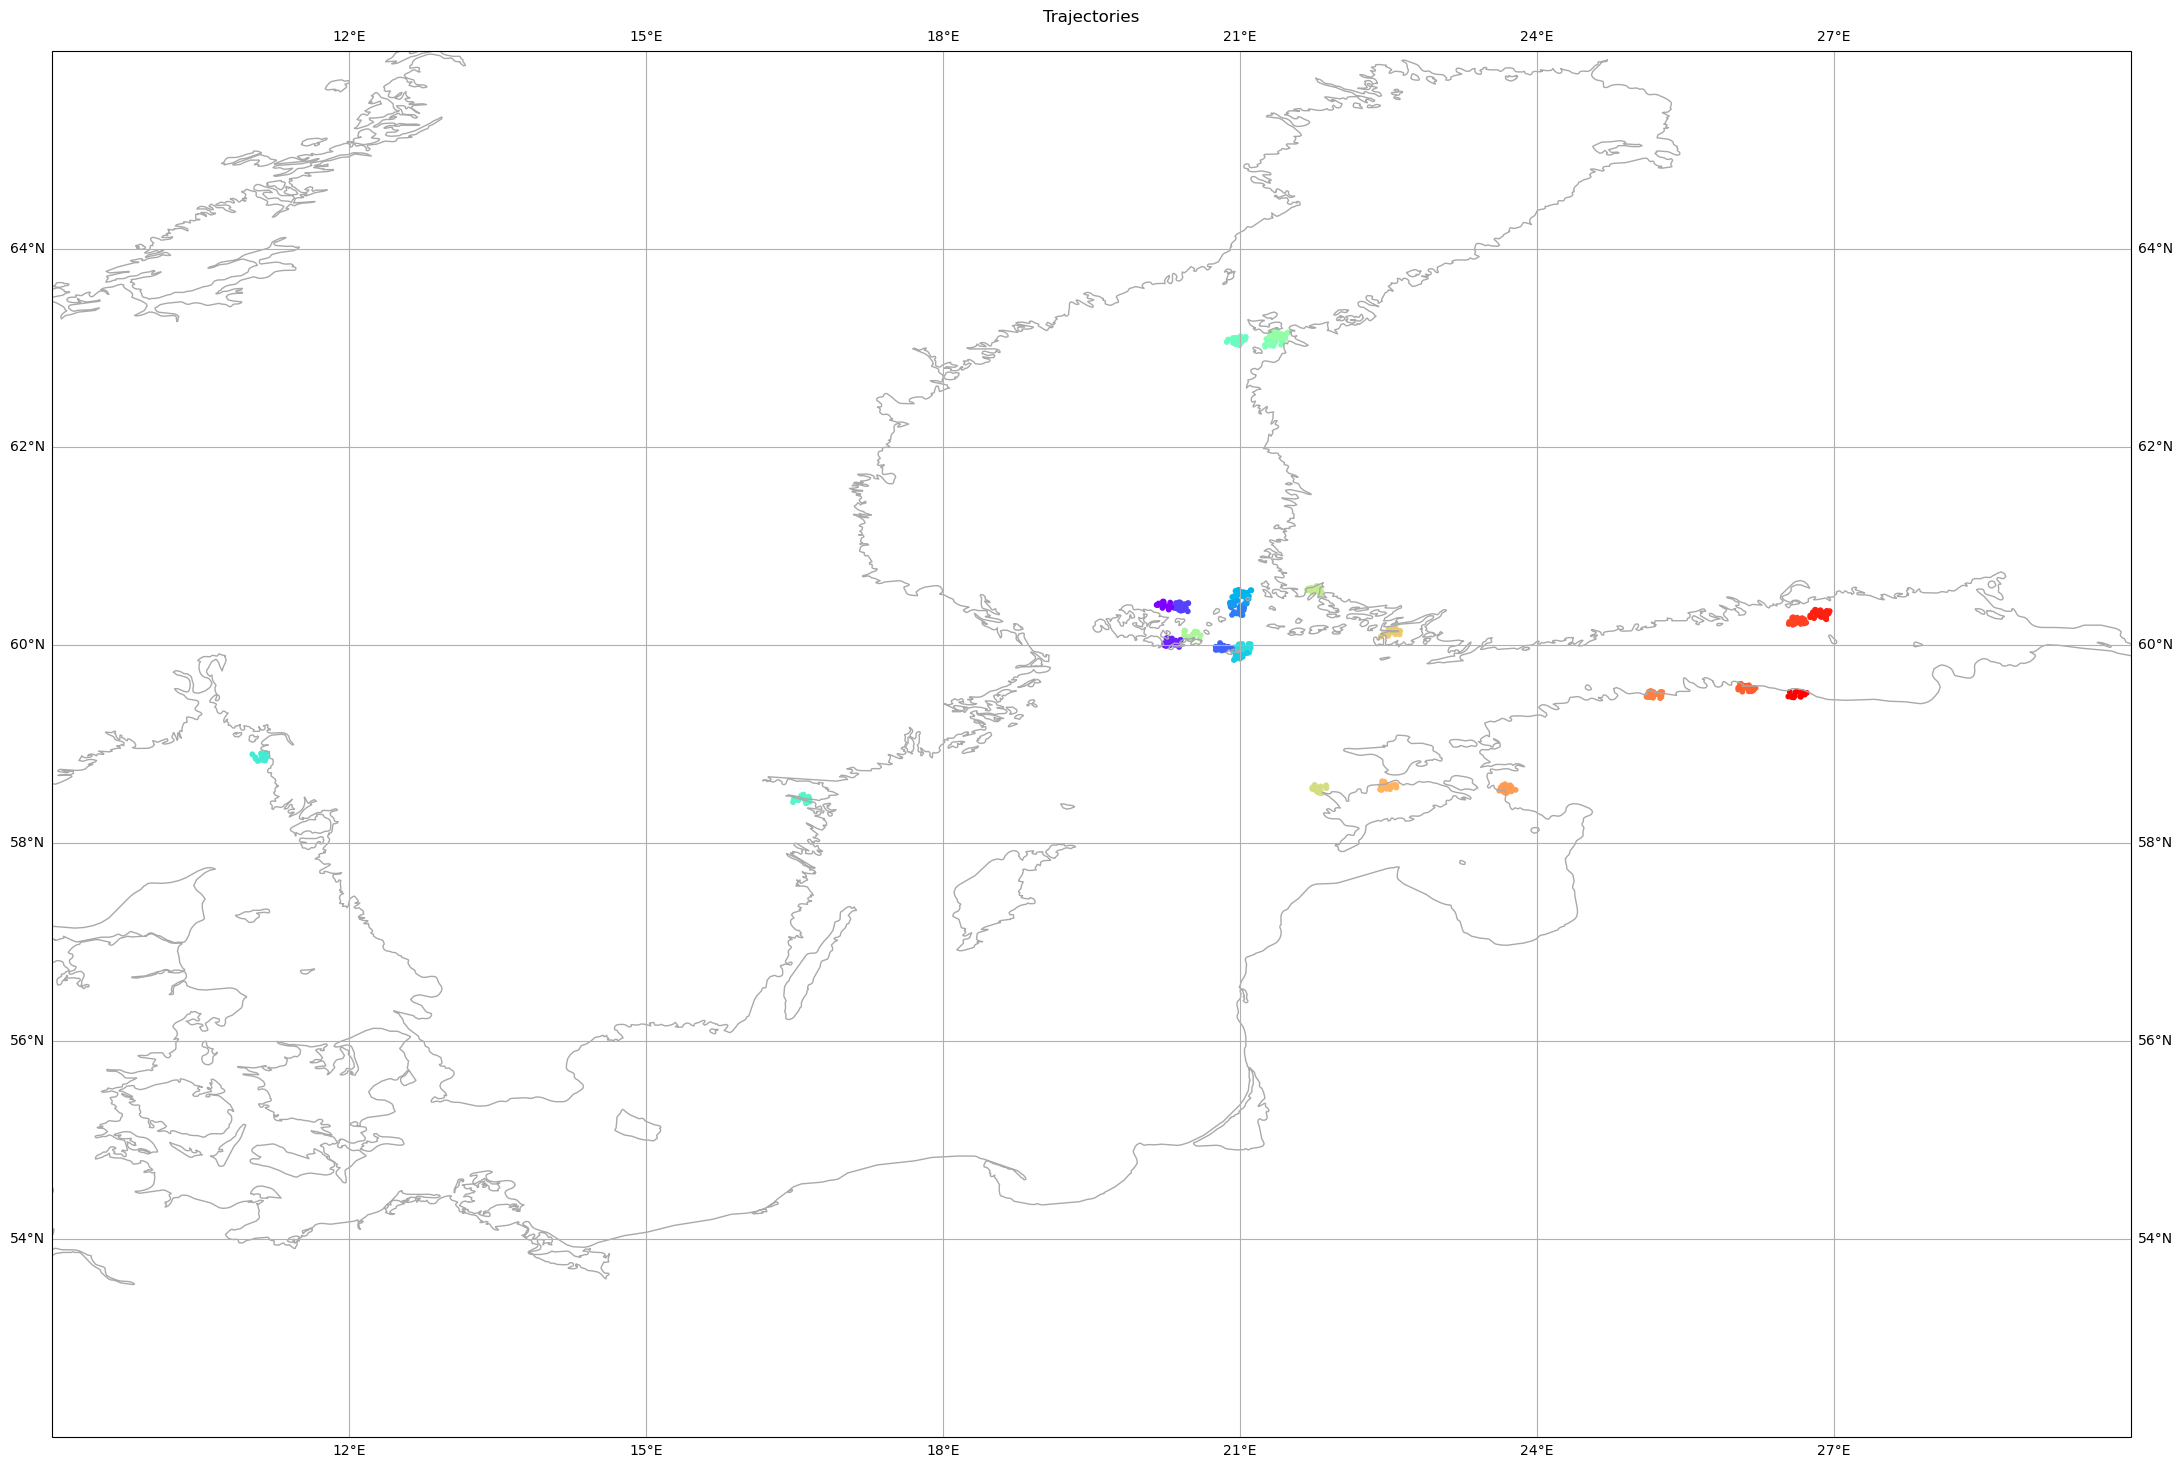

In [11]:
fig = plt.figure(figsize=(30,18))
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
ax.scatter(
        x=ds_trajectories.isel(obs=0).lon, y=ds_trajectories.isel(obs=0).lat,
        c=ds_trajectories.cell_ID , cmap="rainbow",
        s=10,
)
ax.coastlines(color="darkgrey")
ax.gridlines(draw_labels=True)
plt.title("Trajectories")
plt.xlim(lon_min, lon_max)
plt.ylim(lat_min, lat_max)
plt.show()

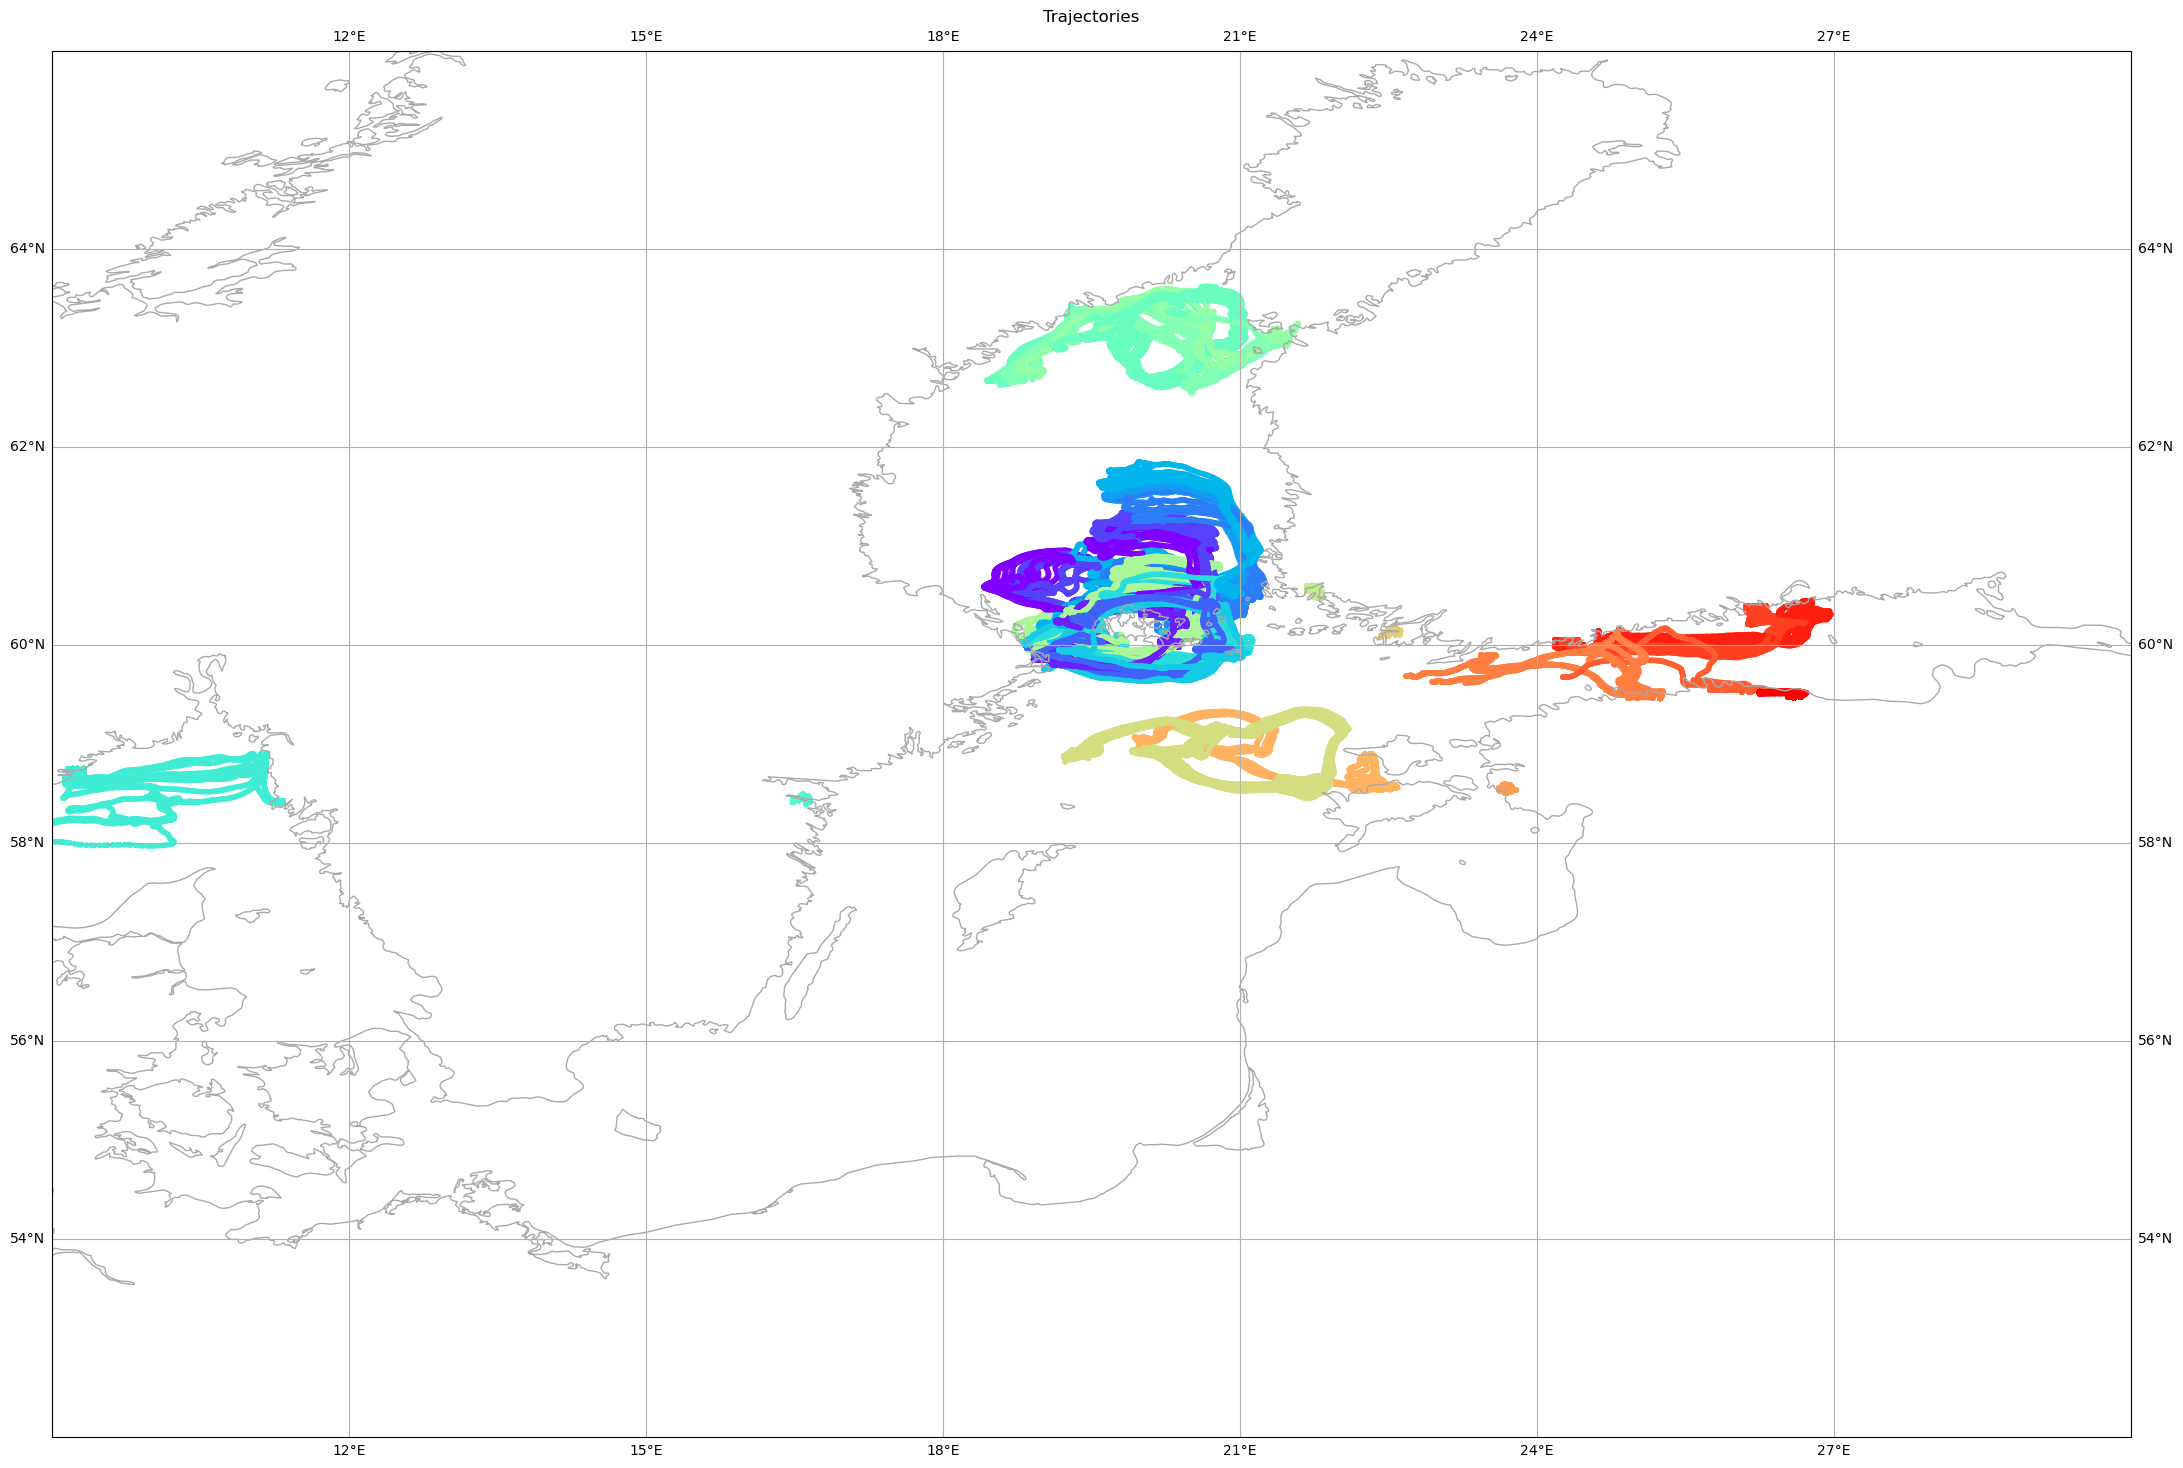

In [12]:
fig = plt.figure(figsize=(30,18))
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
ax.scatter(
        x=ds_trajectories.lon, y=ds_trajectories.lat,
        c=ds_trajectories.cell_IDs, cmap="rainbow",
        s=10,
)
ax.coastlines(color="darkgrey")
ax.gridlines(draw_labels=True)
plt.title("Trajectories")
plt.xlim(lon_min, lon_max)
plt.ylim(lat_min, lat_max)
plt.show()

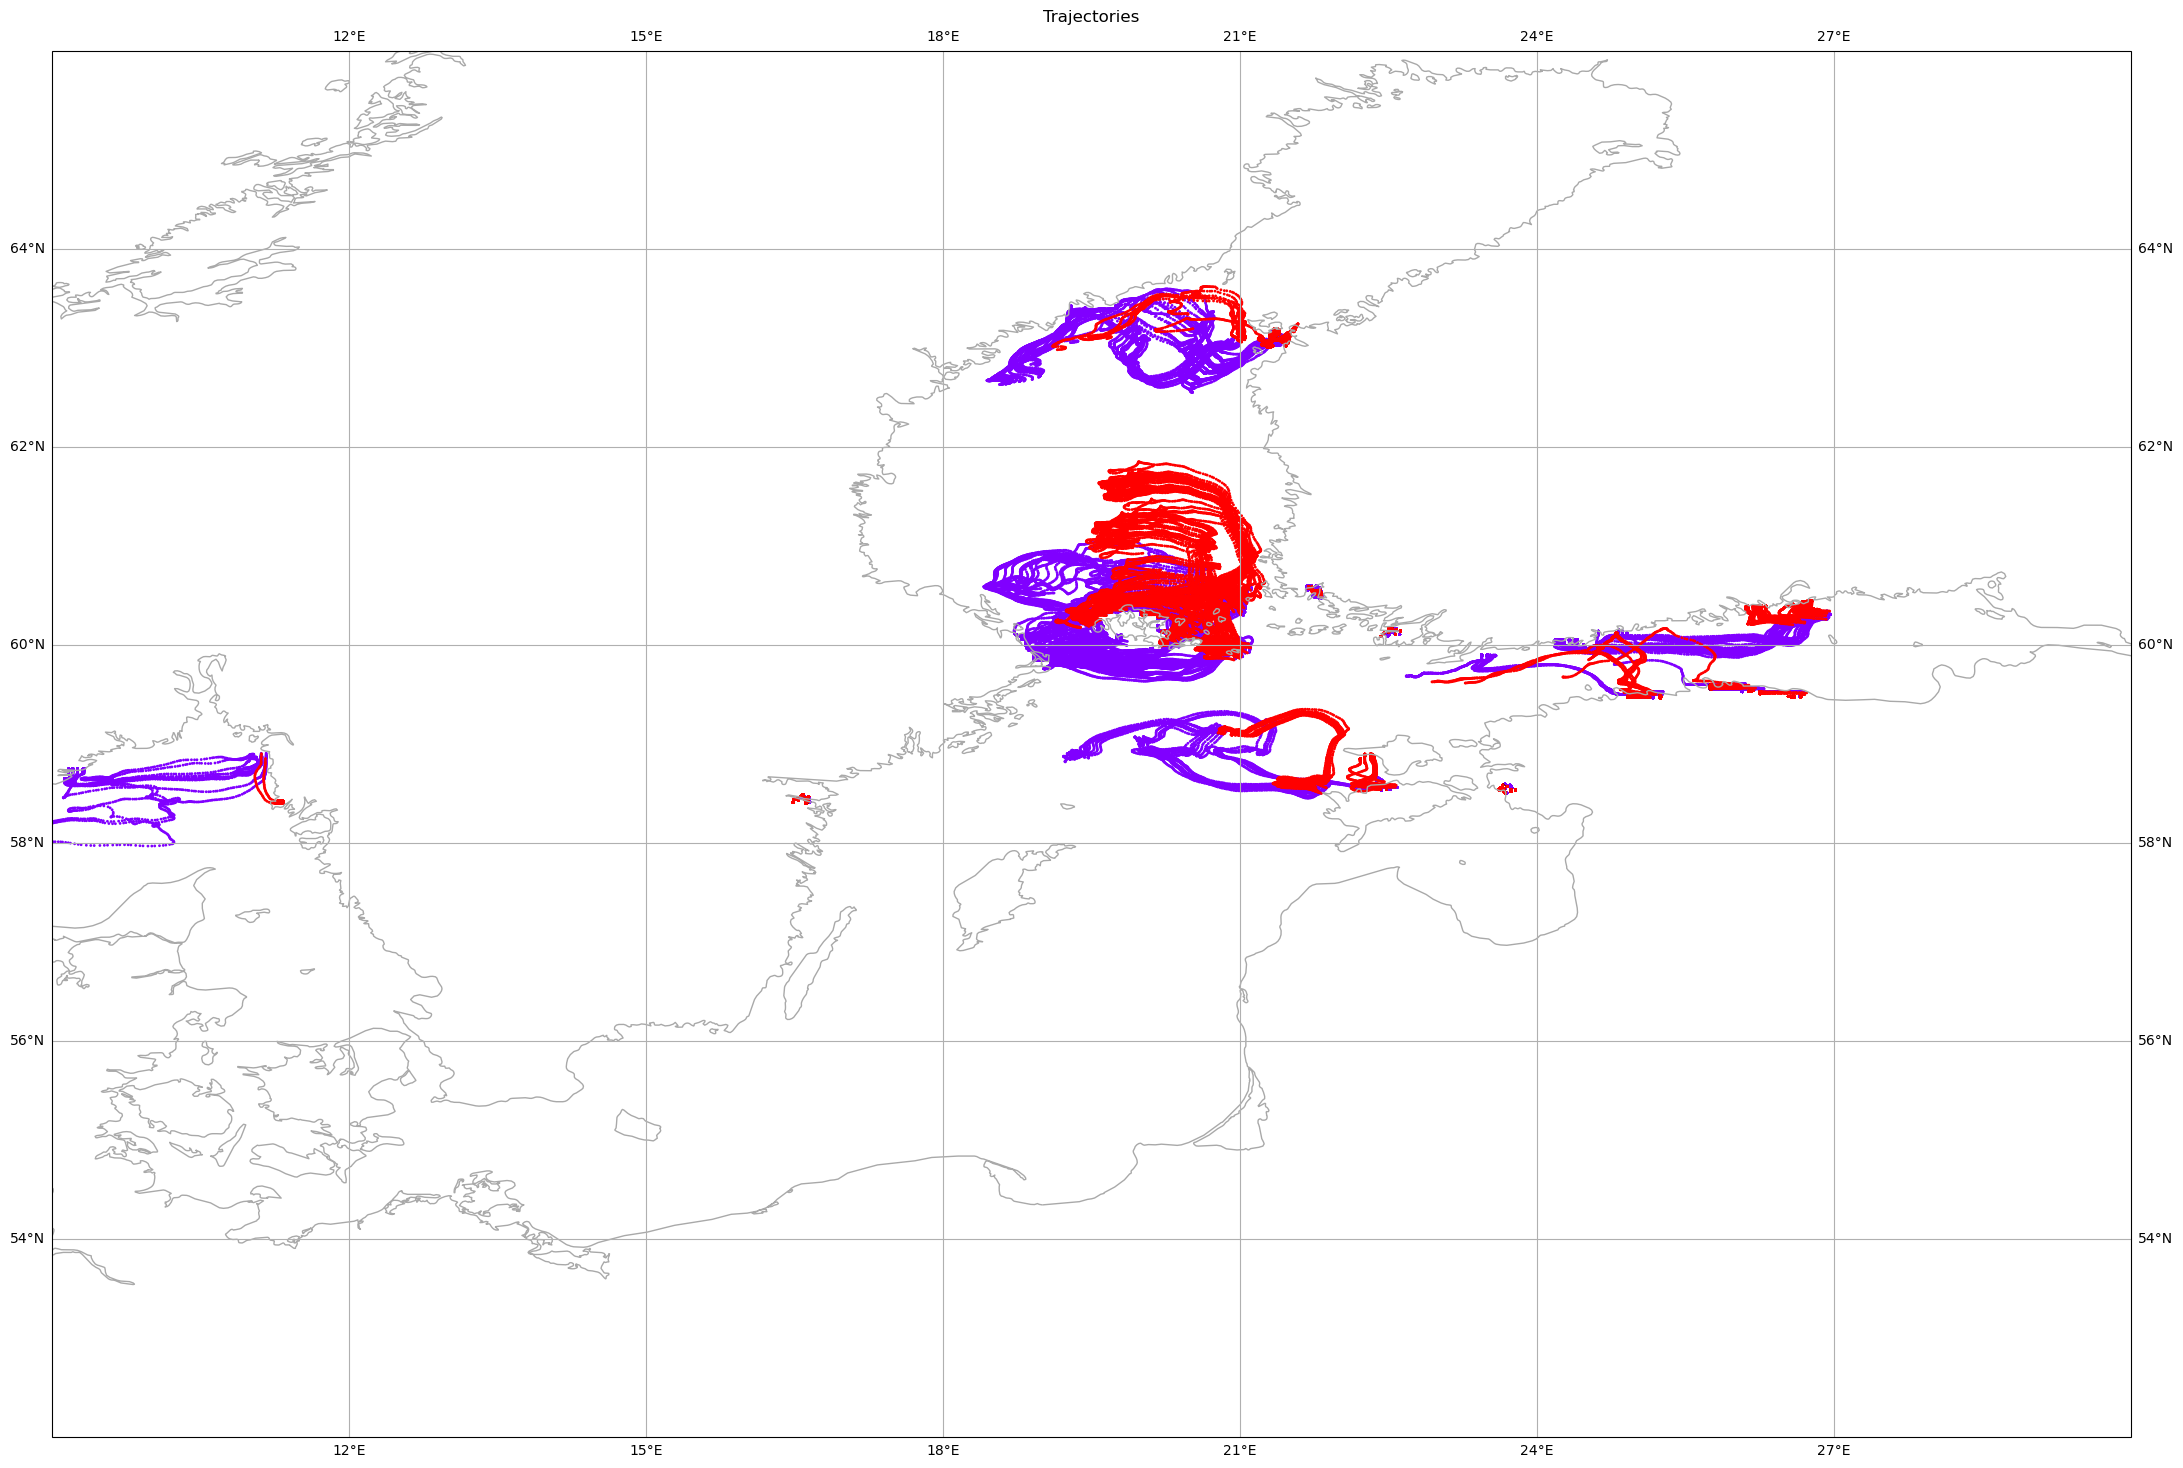

In [13]:
fig = plt.figure(figsize=(30,18))
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
ax.scatter(
        x=ds_trajectories.lon, y=ds_trajectories.lat,
        c=ds_trajectories.release_date, cmap="rainbow",
        s=1,
)
ax.coastlines(color="darkgrey")
ax.gridlines(draw_labels=True)
plt.title("Trajectories")
plt.xlim(lon_min, lon_max)
plt.ylim(lat_min, lat_max)
plt.show()

In [14]:
first_lat = ds_trajectories.isel(obs=0).lat
first_lon = ds_trajectories.isel(obs=0).lon

In [17]:
last_step

<xarray.Dataset> Size: 78kB
Dimensions:          (trajectory: 500)
Coordinates:
    obs              (trajectory) int32 2kB 407 407 407 407 ... 240 240 240 240
  * trajectory       (trajectory) object 4kB MultiIndex
  * trajectory_ID    (trajectory) int64 4kB 0 1 2 3 4 5 ... 495 496 497 498 499
  * cell_ID          (trajectory) int64 4kB 49710 49718 49705 ... 49702 49714
    cell_code        (trajectory) <U12 24kB '10kmE487N448' ... '10kmE496N421'
Data variables:
    cell_IDs         (trajectory) float32 2kB 4.971e+04 4.972e+04 ... 4.971e+04
    S                (trajectory) float32 2kB 5.43 0.0 5.91 ... 0.0 6.01 6.21
    T                (trajectory) float32 2kB 1.865 0.0 2.543 ... 0.0 1.14 -0.34
    age_sec          (trajectory) float32 2kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    lat              (trajectory) float64 4kB 62.63 58.54 60.64 ... 60.19 60.49
    lon              (trajectory) float64 4kB 18.58 23.67 19.89 ... 19.47 21.82
    time             (trajectory) datetime64[ns] 4kB 2021-01-18T05:44:59.7120...
    z                (trajectory) float64 4kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    release_date     (trajectory) datetime64[ns] 4kB 2021-01-01T06:45:00 ... ...
    valid_obs_count  (trajectory) int64 4kB 408 408 408 408 ... 241 241 241 241
    lat_diff         (trajectory) float64 4kB -0.4132 0.0 0.0849 ... nan nan nan
    lon_diff         (trajectory) float64 4kB -2.407 0.0 -1.086 ... nan nan nan
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        NewParticleAdvectionRK4_2D_SIGMABSHdelete_error_p...
    parcels_mesh:           spherical
    parcels_version:        3.0.6

In [20]:
ds_trajectories.lat

<xarray.DataArray 'lat' (trajectory: 500, obs: 408)> Size: 2MB
array([[63.0449005 , 63.03751777, 63.03318411, ..., 62.63612702,
        62.63305079, 62.63173861],
       [58.53992465, 58.53992465, 58.53992465, ..., 58.53992465,
        58.53992465, 58.53992465],
       [60.55735132, 60.55870534, 60.55935029, ..., 60.64401585,
        60.6428792 , 60.64225426],
       ...,
       [60.22133508, 60.22342017, 60.22629395, ...,         nan,
                nan,         nan],
       [59.94605893, 59.94792291, 59.95058055, ...,         nan,
                nan,         nan],
       [60.5305007 , 60.53083196, 60.53068795, ...,         nan,
                nan,         nan]])
Coordinates:
  * obs            (obs) int32 2kB 0 1 2 3 4 5 6 ... 401 402 403 404 405 406 407
  * trajectory     (trajectory) object 4kB MultiIndex
  * trajectory_ID  (trajectory) int64 4kB 0 1 2 3 4 5 ... 495 496 497 498 499
  * cell_ID        (trajectory) int64 4kB 49710 49718 49705 ... 49702 49714
    cell_code      (trajectory) <U12 24kB '10kmE487N448' ... '10kmE496N421'
Attributes:
    axis:           Y
    long_name:      
    standard_name:  latitude
    units:          degrees_north

In [19]:
last_valid_obs = ds_trajectories.obs.where(ds_trajectories.lon.notnull()).max('obs').astype(int)
last_step = ds_trajectories.isel(obs=last_valid_obs).compute()

last_lon = last_step.lon
last_lat = last_step.lat

last_step.to_dataframe()[["lat", "lon", "lat_diff", "lon_diff", "obs", "release_date", "age_sec"]].describe()

,lat,lon,lat_diff,lon_diff,obs,release_date,age_sec
count,500.000000,500.000000,250.000000,250.000000,500.000000,500,500.0
mean,60.320364,20.954227,-0.071786,-1.419880,323.500000,2021-01-04 18:22:30.000000256,0.0
min,57.957499,7.338838,-0.950721,-3.823967,240.000000,2021-01-01 06:45:00,0.0
25%,59.558420,19.274368,-0.208551,-2.322919,240.000000,2021-01-01 06:45:00,0.0
50%,60.188030,20.066923,-0.050672,-1.483002,323.500000,2021-01-04 18:22:30,0.0
75%,60.604712,23.315330,0.000000,-0.441091,407.000000,2021-01-08 06:00:00,0.0
max,63.518603,26.774285,0.475535,0.035970,407.000000,2021-01-08 06:00:00,0.0
std,1.246210,3.292199,0.222808,0.930093,83.583625,NaN,0.0


In [7]:
traj_dead = ds_trajectories.where(first_lon == last_lon, drop=True)
traj_moving = ds_trajectories.where(first_lon != last_lon, drop=True)

In [9]:
# open depth files and define depth cmap
path_static_files = Path("/gxfs_work/geomar/smomw122/bsh_operationalmodel_data")
path_static_fine = path_static_files / "static_file_fine"
path_static_coarse = path_static_files / "static_file_coarse"
depth_coarse = xr.open_dataset(path_static_coarse / "H0_file_coarse.nc").H0
depth_fine = xr.open_dataset(path_static_fine / "H0_file_fine.nc").H0
cm_deep = cmocean.cm.deep

In [13]:
traj_lat = np.concatenate(traj_moving.lat.values)
traj_lon = np.concatenate(traj_moving.lon.values)

traj_lat = traj_lat[np.invert(np.isnan(traj_lat,))]
traj_lon = traj_lon[np.invert(np.isnan(traj_lon,))]

In [14]:
hist, xedges, yedges = np.histogram2d(
        x=traj_lon, y=traj_lat, 
        bins=(lon_range*4, lat_range*4), 
        range=[[lon_min, lon_max], [lat_min, lat_max]],
)

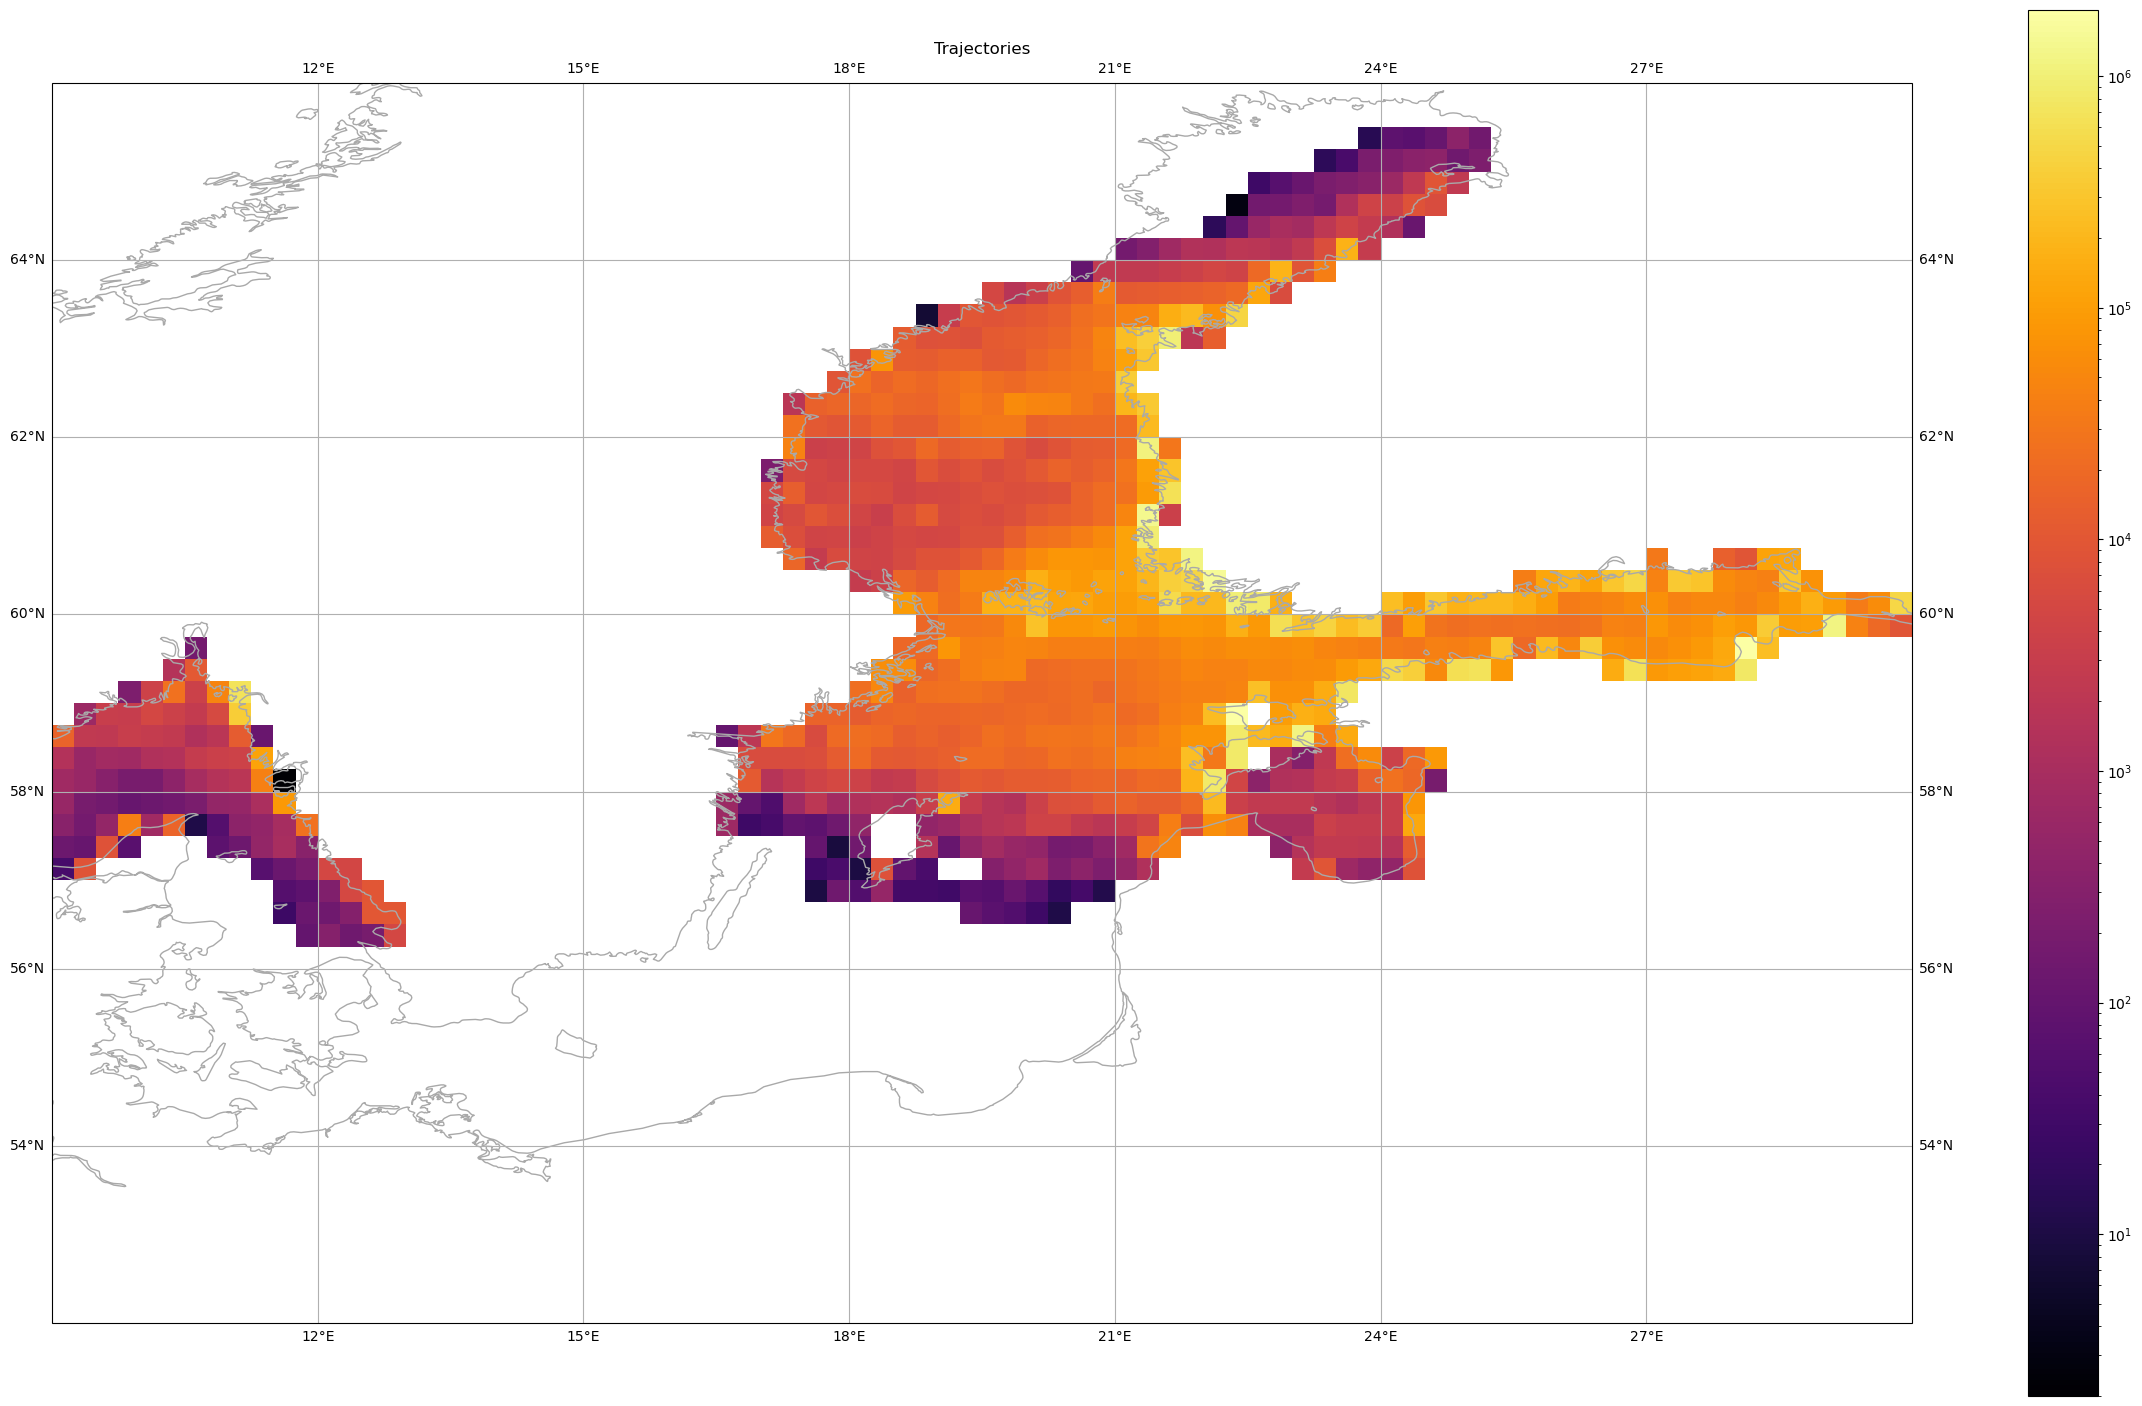

In [18]:
fig = plt.figure(figsize=(30,18))
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
hm = ax.pcolormesh(
        xedges, yedges, hist.T, 
        cmap="inferno", norm=LogNorm(),
        transform=ccrs.PlateCarree(),
)
fig.colorbar(hm)
ax.coastlines(color="darkgrey")
ax.gridlines(draw_labels=True)
plt.title("Trajectories")
plt.xlim(lon_min, lon_max)
plt.ylim(lat_min, lat_max)
plt.show()

In [403]:
trajectory_IDs_per_start_month = [
        data.trajectory.values 
        for month, data 
        in list(traj_moving.isel(obs=0).groupby("time.month"))
]

In [425]:
i=0
for month in trajectory_IDs_per_start_month:
        lons = traj_moving.sel(trajectory=month).lon.values
        lats = traj_moving.sel(trajectory=month).lat.values

        traj_lat = np.concatenate(lats)
        traj_lon = np.concatenate(lons)

        hist, xedges, yedges = np.histogram2d(
                x=traj_lon, y=traj_lat, 
                bins=(lon_range*4*2, lat_range*4*2), 
                range=[[lon_min, lon_max], [lat_min, lat_max]],
        )
        if i == 0:
                monthly_data = hist
                i =+ 1
        else:
                monthly_data = np.dstack((monthly_data, hist))
monthly_data.shape

(168, 112, 12)

In [433]:
xedges, yedges = np.arange(lon_range*4*2), np.arange(lat_range*4*2)
da_monthly = xr.DataArray(
        data=monthly_data,
        coords=dict(
                lon=xedges,
                lat=yedges,
                month=np.arange(1,13),
        ),
        dims=["lon", "lat", "month"]
)

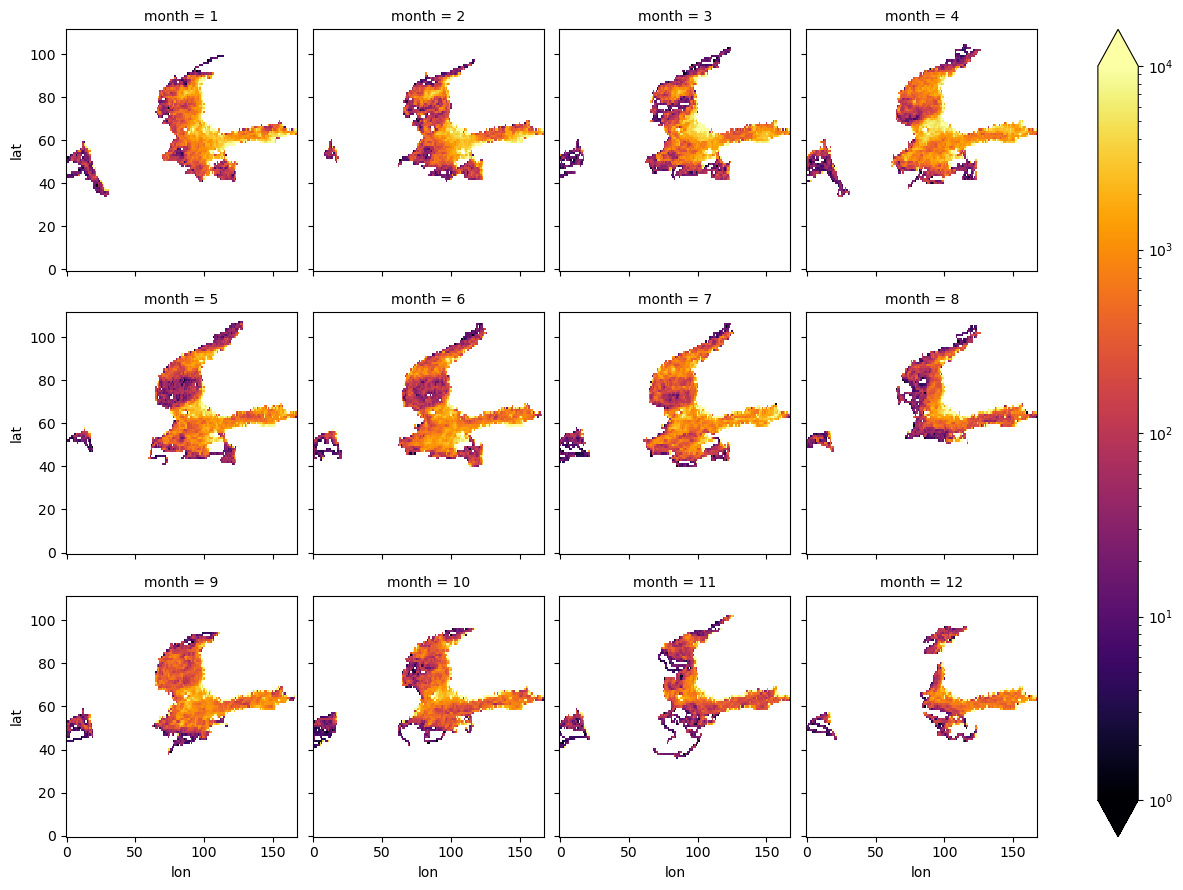

In [441]:
da_monthly.plot(x="lon", y="lat", col="month", col_wrap=4, norm=LogNorm(vmin=1, vmax=1e4), cmap="inferno")


In [242]:
obs_IDs_per_ten_days_of_age = [
        data.obs.values for age_10d, data in 
        list(traj_moving.isel(trajectory=0).groupby_bins(group="age_sec", bins=np.arange(0,221*60*60*24,10*60*60*24)))
]

In [426]:
i=0
for obs in obs_IDs_per_ten_days_of_age:
        lons = traj_moving.isel(obs=obs).lon.values
        lats = traj_moving.isel(obs=obs).lat.values

        traj_lat = np.concatenate(lats)
        traj_lon = np.concatenate(lons)

        hist, xedges, yedges = np.histogram2d(
                x=traj_lon, y=traj_lat, 
                bins=(lon_range*4*2, lat_range*4*2), 
                range=[[lon_min, lon_max], [lat_min, lat_max]],
        )
        if i == 0:
                age_data = hist
                i =+ 1
        else:
                age_data = np.dstack((age_data, hist))
age_data.shape

(168, 112, 22)

In [442]:
xedges, yedges = np.arange(lon_range*4*2), np.arange(lat_range*4*2)
da_age = xr.DataArray(
        data=age_data,
        coords=dict(
                lon=xedges,
                lat=yedges,
                obs=np.arange(0,220,10),
        ),
        dims=["lon", "lat", "obs"]
)

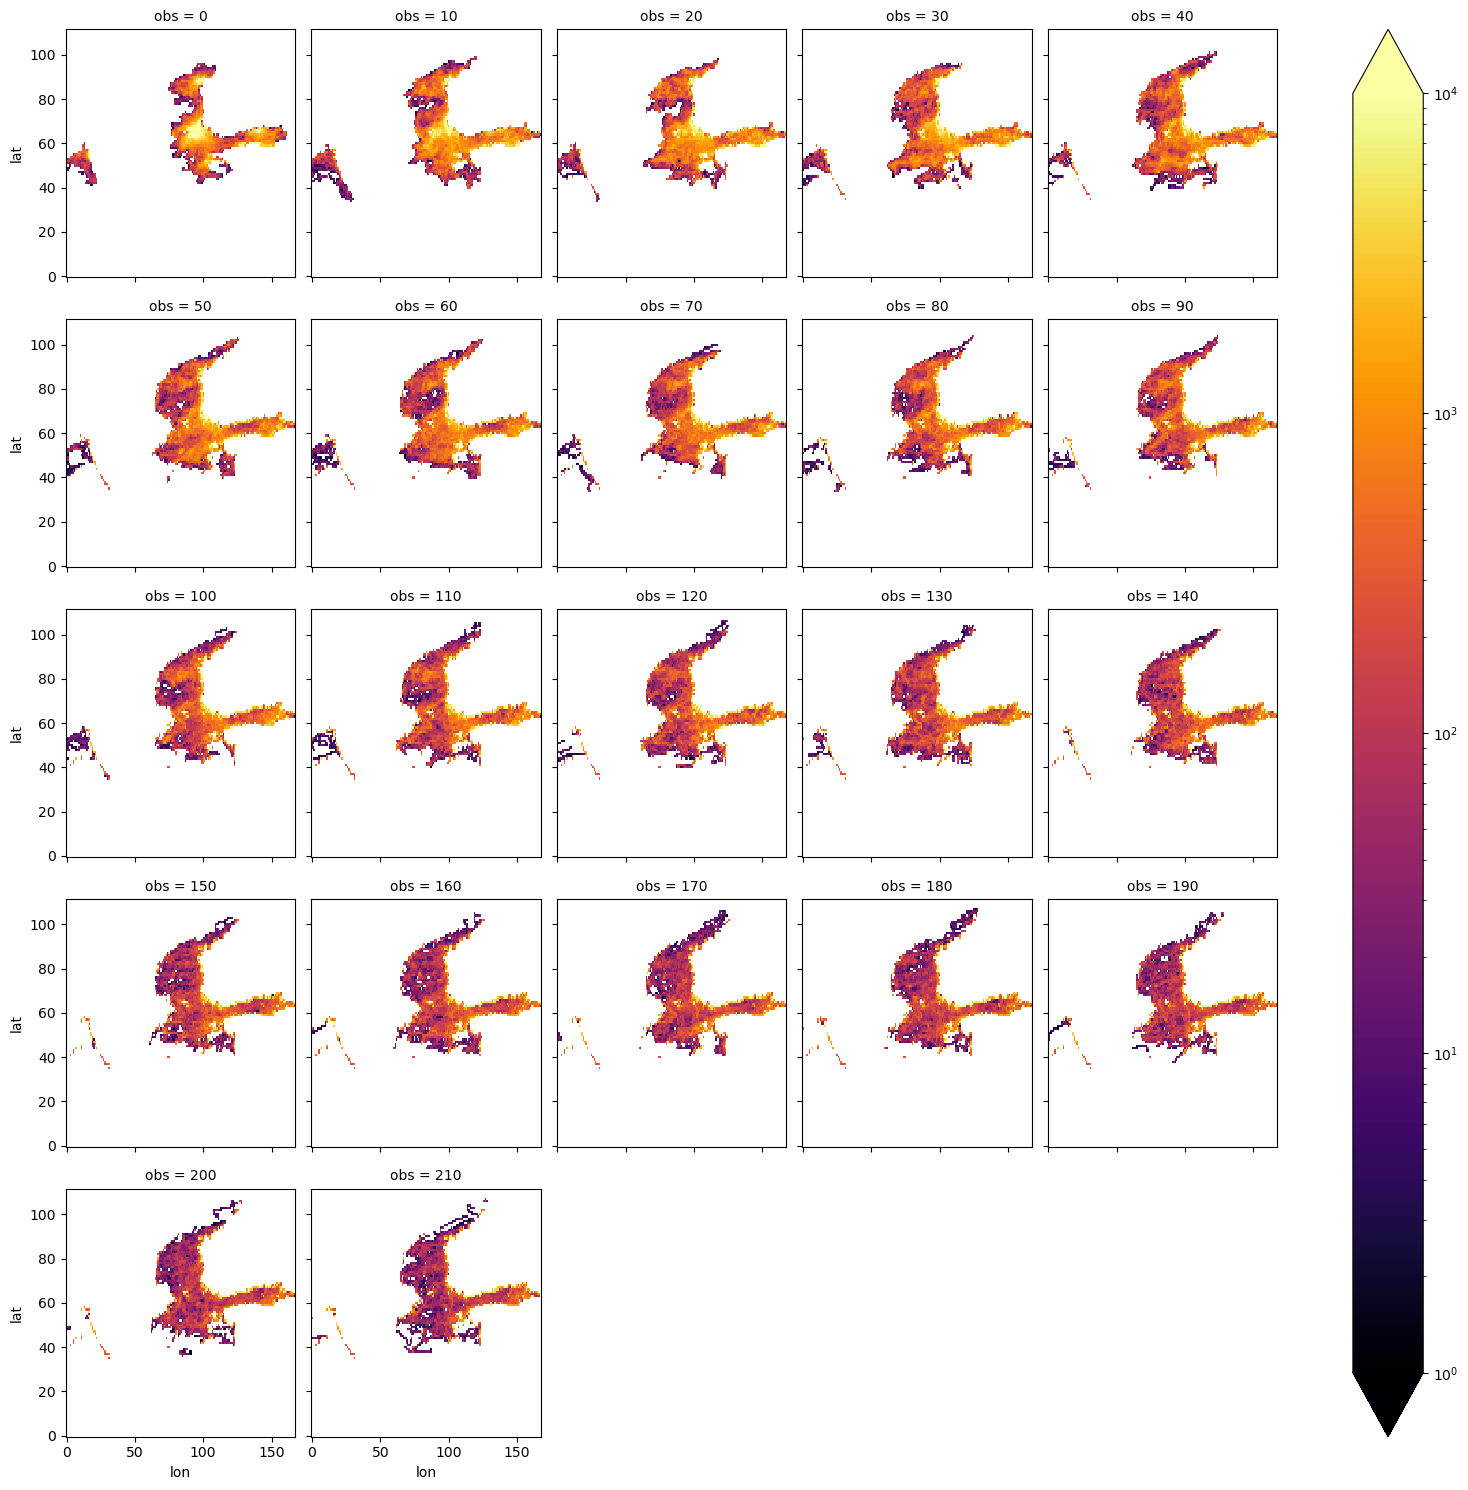

In [445]:
da_age.plot(x="lon", y="lat", col="obs", col_wrap=5, norm=LogNorm(vmin=1, vmax=1e4), cmap="inferno")


In [302]:
month = 4
lats = traj_moving.isel(trajectory=trajectory_IDs_per_start_month[month]).lat.values
lons = traj_moving.isel(trajectory=trajectory_IDs_per_start_month[month]).lon.values

traj_lat = np.concatenate(lats)
traj_lon = np.concatenate(lons)

traj_lat = traj_lat[np.invert(np.isnan(traj_lat,))]
traj_lon = traj_lon[np.invert(np.isnan(traj_lon,))]
hist, xedges, yedges = np.histogram2d(
        x=traj_lon, y=traj_lat, 
        bins=(lon_range*4*2, lat_range*4*2), 
        range=[[lon_min, lon_max], [lat_min, lat_max]],
)

latlon = np.meshgrid(xedges,yedges)


da_latlon = xr.DataArray(
        data=latlon[1].T,
        coords=dict(
                lat=yedges,
                lon=xedges,
        ),
        dims=["lon", "lat"]
)
da_latlon

<xarray.DataArray (lon: 169, lat: 113)> Size: 153kB
array([[52.   , 52.125, 52.25 , ..., 65.75 , 65.875, 66.   ],
       [52.   , 52.125, 52.25 , ..., 65.75 , 65.875, 66.   ],
       [52.   , 52.125, 52.25 , ..., 65.75 , 65.875, 66.   ],
       ...,
       [52.   , 52.125, 52.25 , ..., 65.75 , 65.875, 66.   ],
       [52.   , 52.125, 52.25 , ..., 65.75 , 65.875, 66.   ],
       [52.   , 52.125, 52.25 , ..., 65.75 , 65.875, 66.   ]])
Coordinates:
  * lat      (lat) float64 904B 52.0 52.12 52.25 52.38 ... 65.75 65.88 66.0
  * lon      (lon) float64 1kB 9.0 9.125 9.25 9.375 ... 29.62 29.75 29.88 30.0

In [155]:
xr.plot.contour(latlon, x=traj_moving.lon, y=traj_moving.lat)

AttributeError: 'list' object has no attribute 'ndim'

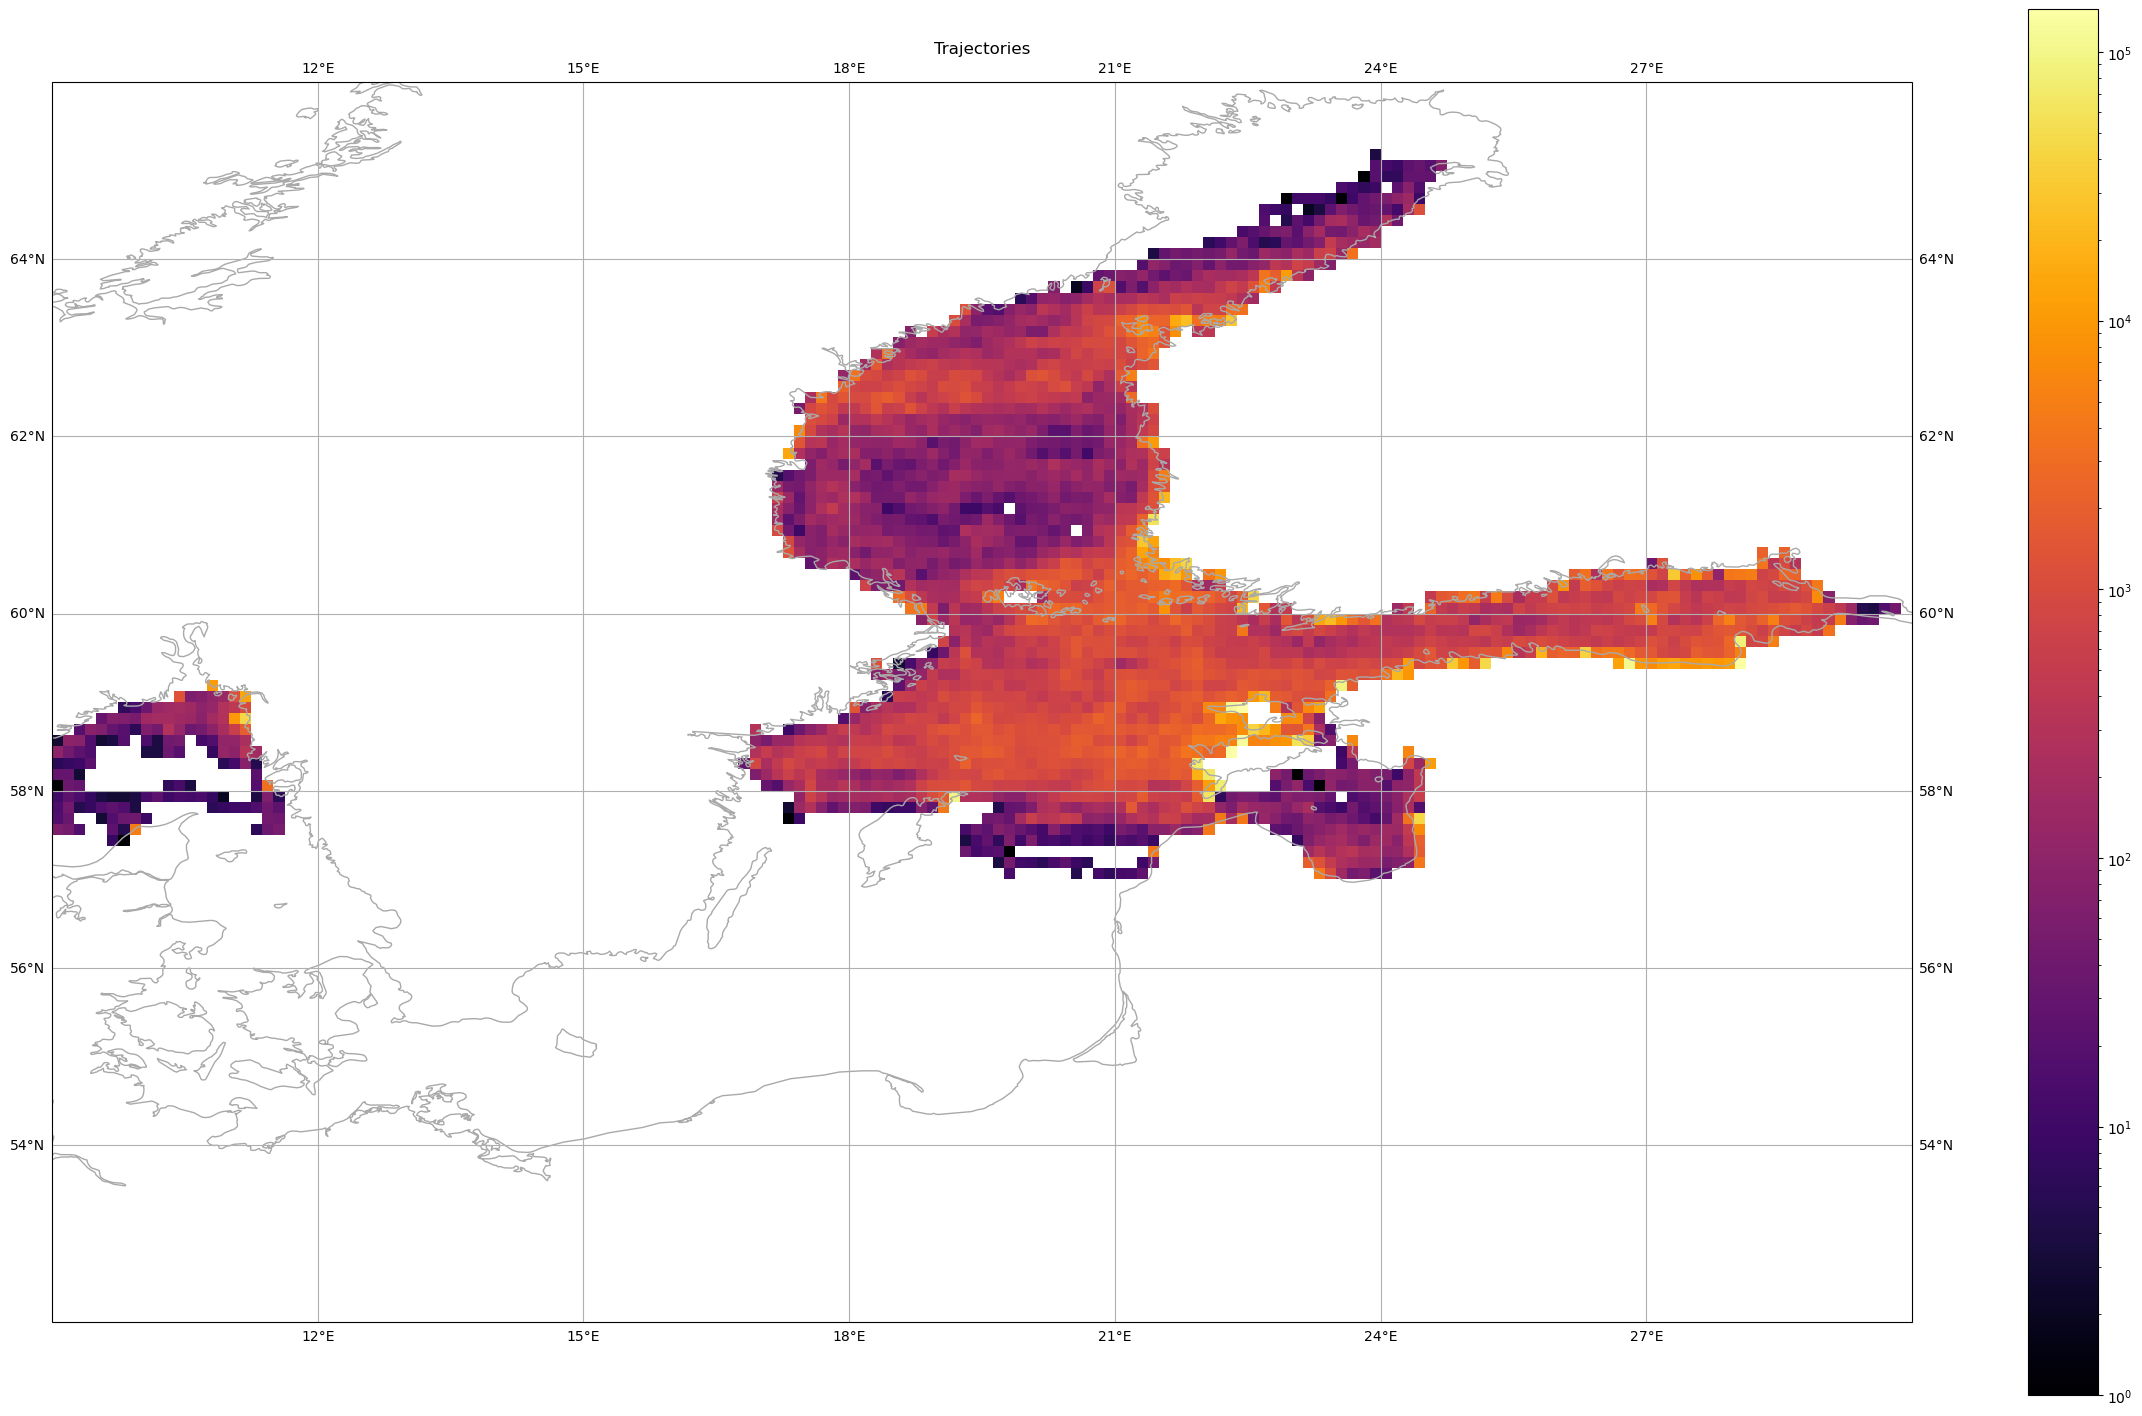

In [316]:
month = 4
lats = traj_moving.isel(trajectory=trajectory_IDs_per_start_month[month]).lat.values
lons = traj_moving.isel(trajectory=trajectory_IDs_per_start_month[month]).lon.values

traj_lat = np.concatenate(lats)
traj_lon = np.concatenate(lons)

traj_lat = traj_lat[np.invert(np.isnan(traj_lat,))]
traj_lon = traj_lon[np.invert(np.isnan(traj_lon,))]
hist, xedges, yedges = np.histogram2d(
        x=traj_lon, y=traj_lat, 
        bins=(lon_range*4*2, lat_range*4*2), 
        range=[[lon_min, lon_max], [lat_min, lat_max]],
)

fig = plt.figure(figsize=(30,18))
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
hm = ax.pcolormesh(
        xedges, yedges, hist.T, 
        cmap="inferno", norm=LogNorm(),
        transform=ccrs.PlateCarree(),
)
fig.colorbar(hm)
ax.coastlines(color="darkgrey")
ax.gridlines(draw_labels=True)
plt.title("Trajectories")
plt.xlim(lon_min, lon_max)
plt.ylim(lat_min, lat_max)
plt.show()

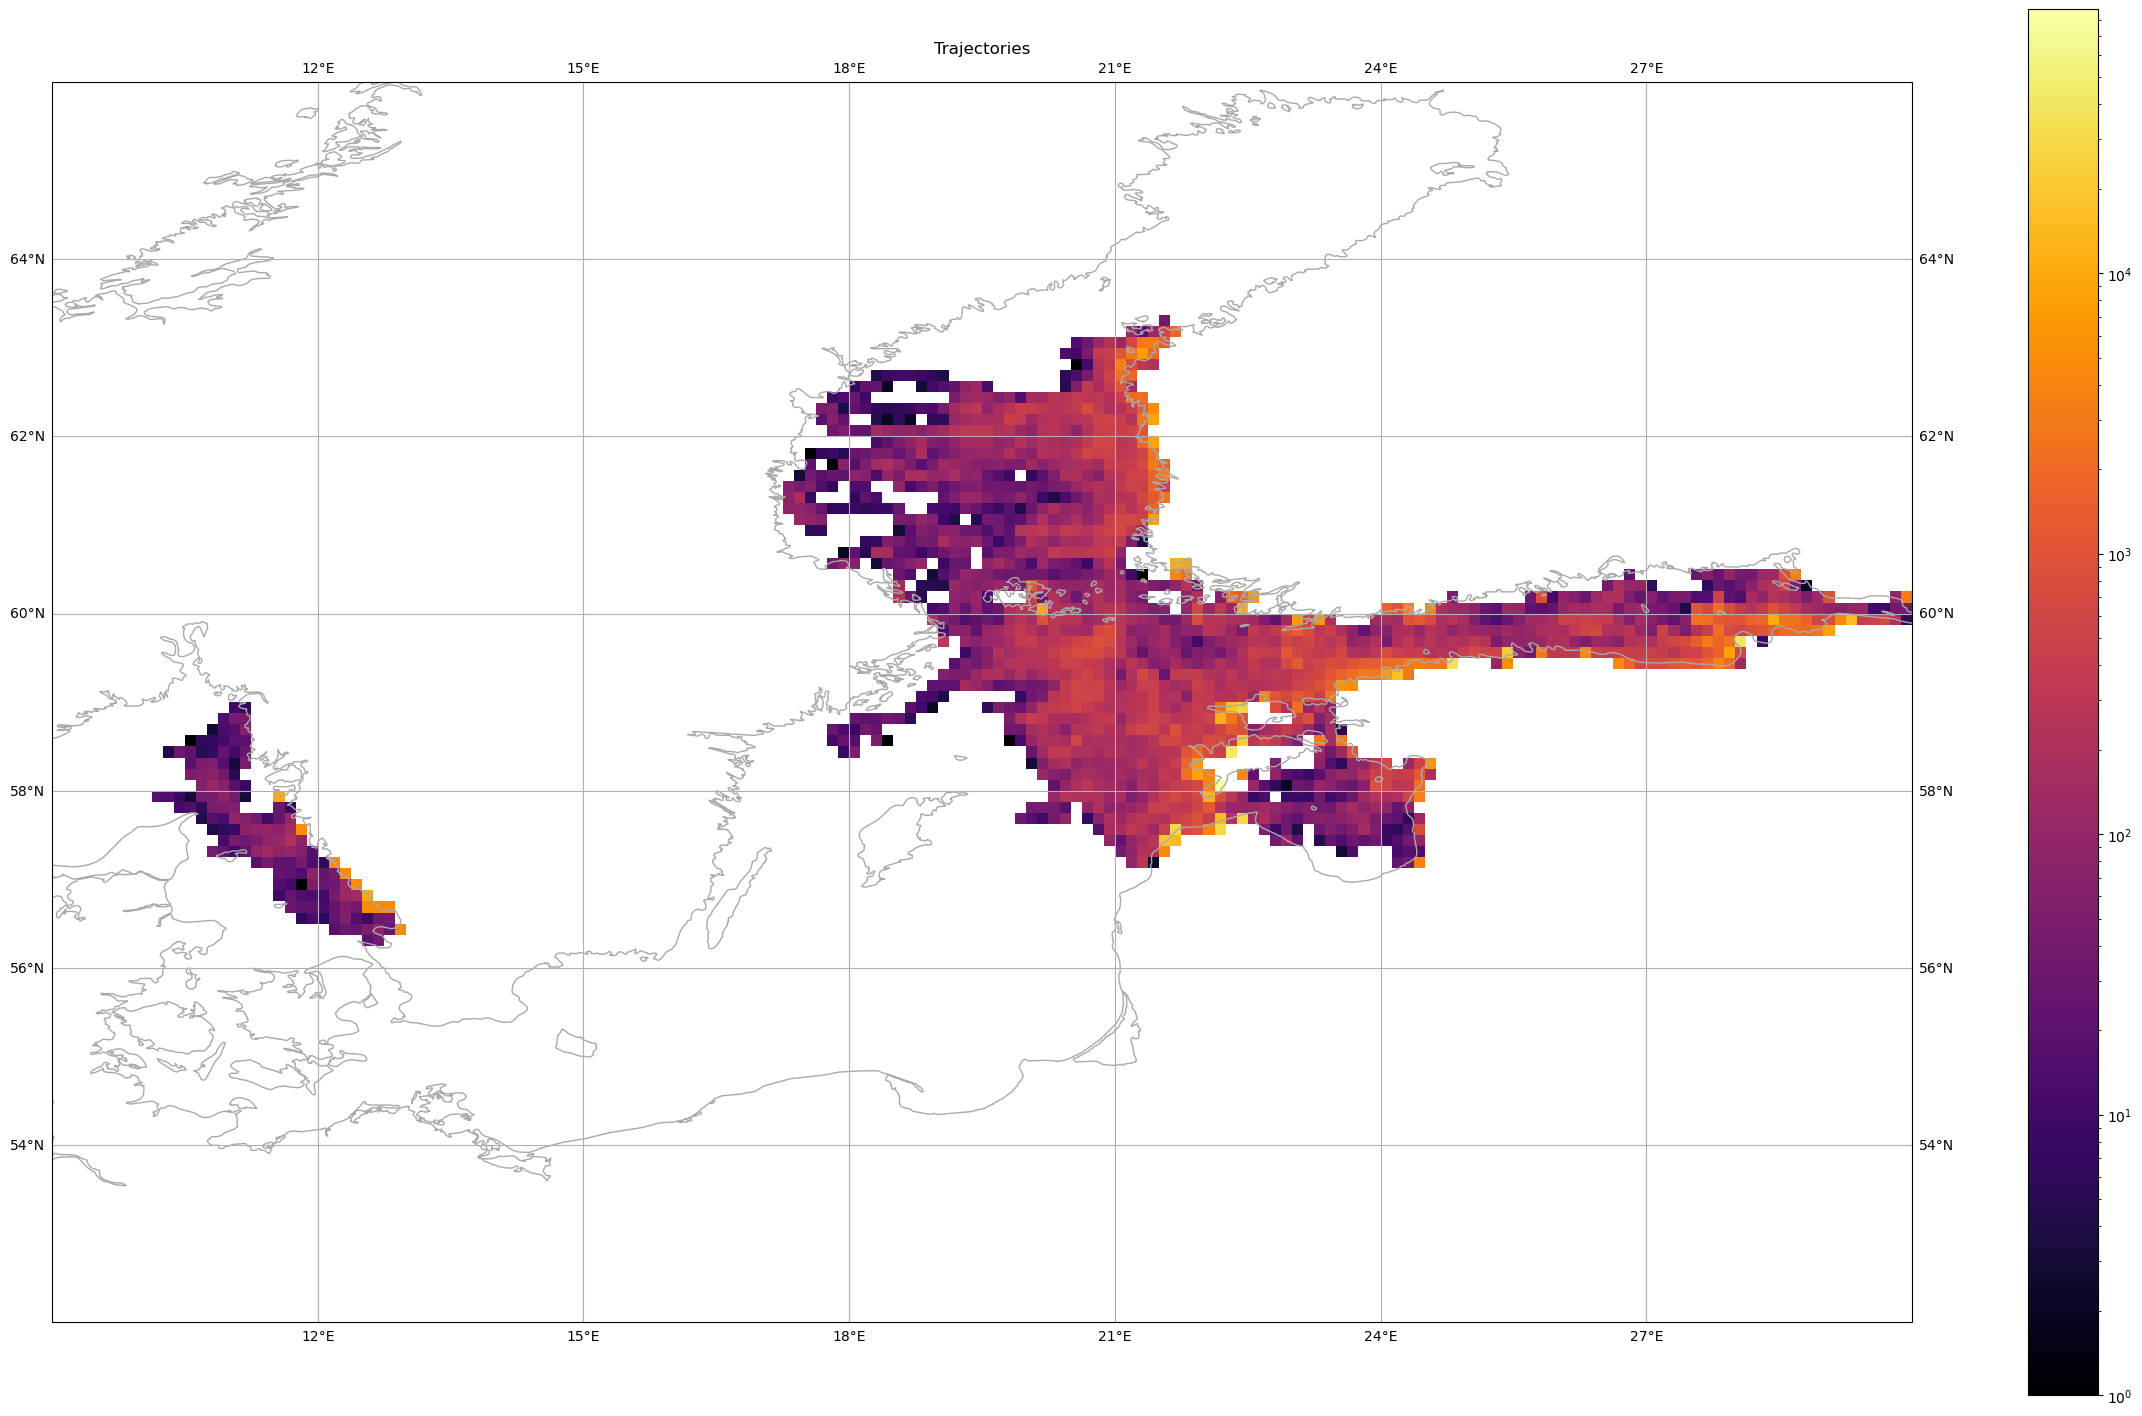

In [82]:
age_10days = 0
lats = traj_moving.isel(trajectory=obs_IDs_per_ten_days_of_age[age_10days]).lat.values
lons = traj_moving.isel(trajectory=obs_IDs_per_ten_days_of_age[age_10days]).lon.values

traj_lat = np.concatenate(lats)
traj_lon = np.concatenate(lons)

traj_lat = traj_lat[np.invert(np.isnan(traj_lat,))]
traj_lon = traj_lon[np.invert(np.isnan(traj_lon,))]
hist, xedges, yedges = np.histogram2d(
        x=traj_lon, y=traj_lat, 
        bins=(lon_range*8, lat_range*8), 
        range=[[lon_min, lon_max], [lat_min, lat_max]],
)

fig = plt.figure(figsize=(30,18))
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
hm = ax.pcolormesh(
        xedges, yedges, hist.T, 
        cmap="inferno", norm=LogNorm(),
        transform=ccrs.PlateCarree(),
)
fig.colorbar(hm)
ax.coastlines(color="darkgrey")
ax.gridlines(draw_labels=True)
plt.title("Trajectories")
plt.xlim(lon_min, lon_max)
plt.ylim(lat_min, lat_max)
plt.show()